In [21]:
import numpy as np # Used for handling numerical arrays
import matplotlib.pyplot as plt # Standard tool for creating plots
import seaborn as sns # Built on top of matplotlib for prettier statistical plots

sns.set_theme()

In [22]:
# X represents our 'Feature' (the data we use to make predictions 
X=np.array([1,3,4,6,7]) # Years of experience

# y represents our 'Target' (the value we want our model to learn to predict)
Y = np.array([15, 35, 45, 65, 75]) # Salary in thousands

## 2. Visualize the Raw Data
Before modeling, we look at the data points to see if a correlateion exist

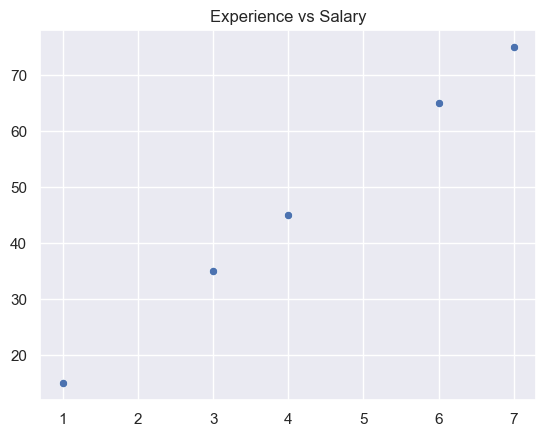

In [23]:
sns.scatterplot(x=X, y=Y)
plt.title("Experience vs Salary")
plt.show()

## 3. Defining the Prediction Function
The function below implements the linear formula for every data point.
- `w` (weight) controls the slope.
- `b` (bias) controls the y-intercept.

In [24]:
def make_prediction(x,y,w,b):
  """
  Calculates predictions using the linear regression formula: y = wx + b
  w: weight (slope)
  b: bias (intercept)
  
  """
 
  m=X.shape[0]    # output:(5,) ..`` ... trainging data  er row ta count kore m e rakha holo
  pred_list=np.zeros((m,)) # prediction er list banano holo,  zeros diye initialize kora holo
  

  
  for i in range(m):
                                   # Calculate the prediction for each specific data point
    pred_list[i] = w * X[i] + b   # moloto y prediction er formula, w * x + b, x er jaygay X[i] deya holo, karon prottek data point er jonno alada prediction calculate korte hobe

  return pred_list

## 4. Experimenting with Parameters
Now we test different values of `w` and `b` to see how well our line fits the data.

Predictions: [0. 0. 0. 0. 0.]


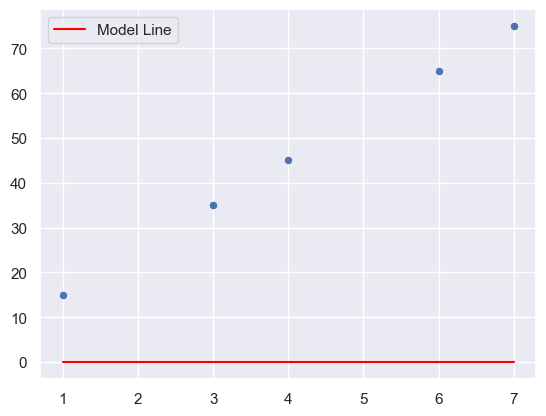

In [25]:
# Start with w=0 and b=0 (flat line at zero)
predictions = make_prediction(X, Y, 0, 0)
print(f"Predictions: {predictions}") # 

# Visualize how this 'zero' model fits the data
sns.scatterplot(x=X, y=Y) # x ,y er man goa oder jaigai ace
plt.plot(X, predictions, color='red', label='Model Line')
plt.legend()
plt.show()

### Case 1: Minimal values
Here $w=1, b=0$. The line is far below the data points.

Predictions: [1. 3. 4. 6. 7.]


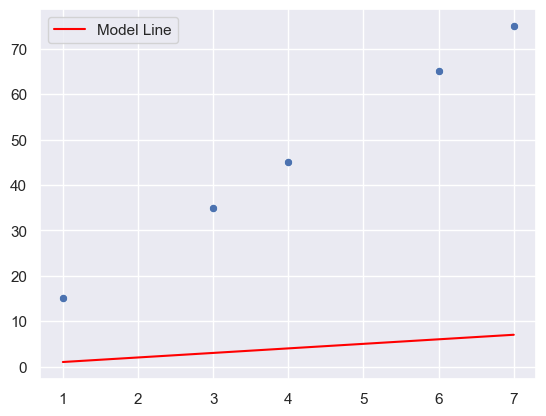

In [26]:
# Try w=1 and b=0
predictions = make_prediction(X, Y, w=1, b=0)
print(f"Predictions: {predictions}")

sns.scatterplot(x=X, y=Y)
plt.plot(X, predictions, color='red', label='Model Line')
plt.legend()
plt.show()

### Case 2: Increasing the slope
Using $w=5, b=3$ brings the line closer, but it's still not quite there.

Predictions: [ 8. 18. 23. 33. 38.]


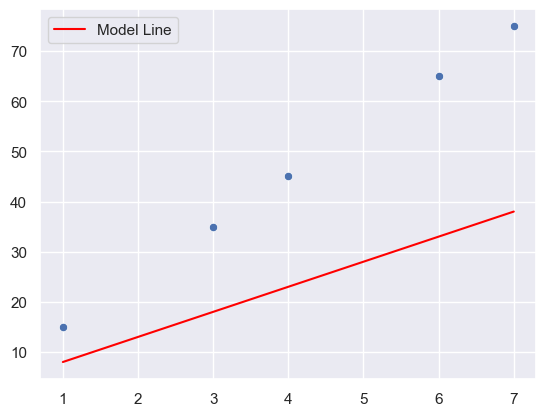

In [27]:
# Try w=5 and b=3 to increase the slope and intercept
predictions = make_prediction(X, Y, w=5, b=3)
print(f"Predictions: {predictions}")

sns.scatterplot(x=X, y=Y)
plt.plot(X, predictions, color='red', label='Model Line')
plt.legend()
plt.show()

### Case 3: Finding a better fit
With $w=10, b=5$, we see a much better alignment with our data points.

Predictions calculated by the model: [15. 35. 45. 65. 75.]


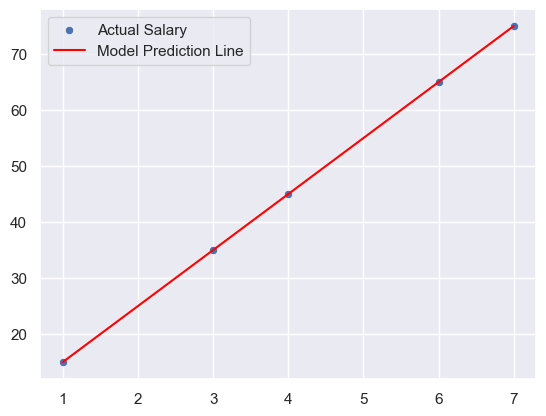

In [28]:
# Experimenting with w=10 and b=5 to see how well the line fits the actual data
predictions = make_prediction(X, Y, w=10, b=5)
print(f"Predictions calculated by the model: {predictions}")

# Plot the actual data points
sns.scatterplot(x=X, y=Y, label='Actual Salary')
# Draw the model's prediction line
plt.plot(X, predictions, color='red', label='Model Prediction Line')
plt.legend()
plt.show()

## Summary
In this notebook, we manually explored how a linear regression model makes predictions. Here are the key takeaways:

1. **Model Parameters**: We saw that $w$ (the weight) controls the steepness or slope of the line, while $b$ (the bias) shifts the line up or down on the y-axis.

2.  When our parameters were too small (like $w=1, b=0$), the line failed to capture the trend of the data.


3. **Finding the 'Best Fit'**: By iterating through different values, we found that $w=10$ and $b=5$ perfectly matched our small dataset. In a real ML project, we use an algorithm called **Gradient Descent** to find these optimal values automatically by minimizing a 'Cost Function'.

We will learn the Cost function code and Gradient Descent in the next module.

3.Cost Function


To evaluate how well our model fits, we calculate the 'Cost' (Mean Squared Error). A lower cost means a better fit.

In [29]:
def compute_cost(X,Y,w,b):
    m = X.shape[0]  # Number of training examples
    cost=0.0
    for i in range(m):
        prediction=w*X[i]+b  # Calculate the predicted value for the i-th training example
        error=prediction-Y[i]  #(difference between predicted and actual value)
        cost=cost+error**2  # akane sob errro jog kora holo, error er square kora holo karon negative error o positive error o same vabe contribute korbe cost e

    cost = cost / (2 * m)  # Divide by 2m to get the average cost
    return cost

Step 1: Error বের করো

Step 2: Error² করো

Step 3: সব Error² যোগ করো  ← SSE

Step 4: 2m দিয়ে ভাগ করো   ← Cost Function

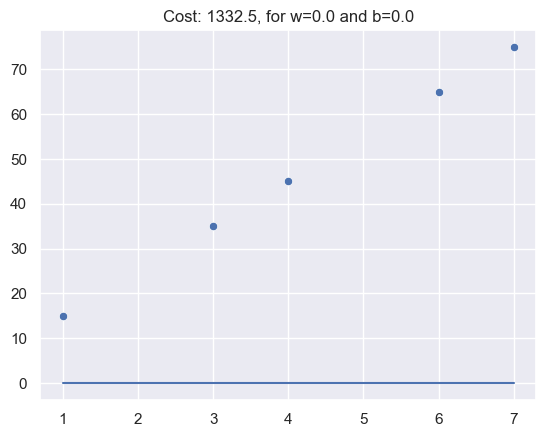

In [30]:
w=0.0
b=0.0
predictions=make_prediction(X,Y,w=w,b=b)
sns.scatterplot(x=X,y=Y)
plt.plot(X,predictions)
plt.title(f"Cost: {compute_cost(X, Y, w=w, b=b)}, for w={w} and b={b}")

# akne compute cost e w=w mane w=0 ,b=b mane b=0 pass kore disi ja title e show kortese

plt.show()



[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Cost: 1100.6, for w =1.0 and b=0.0')

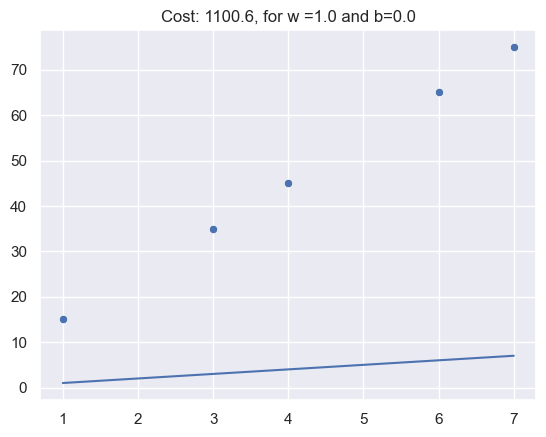

In [ ]:
w=1.0
b=0.0
predictions = make_prediction(X,Y,w=w,b=b)
print(predictions)

sns.scatterplot(x = X , y = Y)
plt.plot(X ,predictions)

plt.title(f"Cost: {compute_cost(X,Y,w=w,b=b)}, for w ={w} and b={b}")

[ 3.  7.  9. 13. 15.]


Text(0.5, 1.0, 'Cost: 852.8, for w =2.0 and b=1.0')

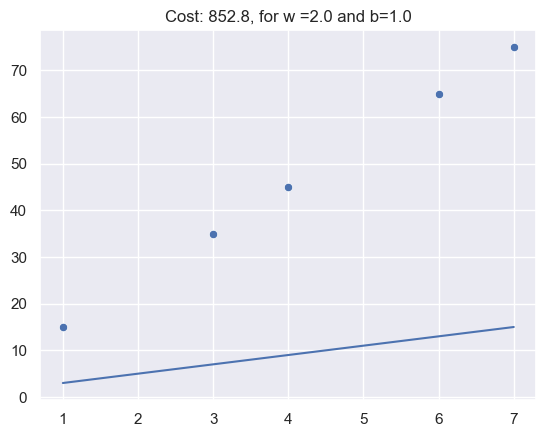

In [33]:
w= 2.0
b= 1.0

predictions = make_prediction(X,Y,w=w,b=b)
print(predictions)

sns.scatterplot(x= X , y = Y)
plt.plot(X ,predictions)

plt.title(f"Cost: {compute_cost(X,Y,w=w,b=b)}, for w ={w} and b={b}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 0.0, for w =10.0 and b=5.0')

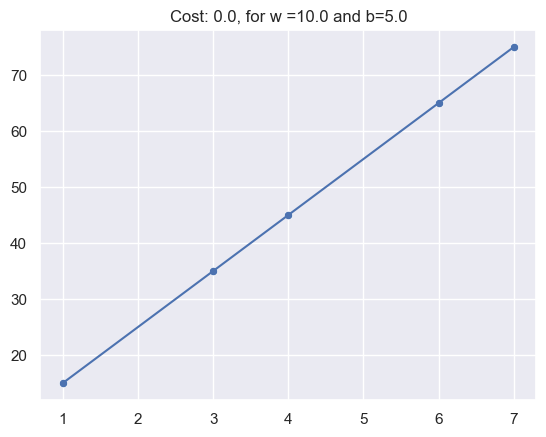

In [35]:
w= 10.0
b= 5.0

predictions = make_prediction(X,Y,w=w,b=b)
print(predictions)

sns.scatterplot(x= X , y = Y)
plt.plot(X ,predictions)

plt.title(f"Cost: {compute_cost(X,Y,w=w,b=b)}, for w ={w} and b={b}")

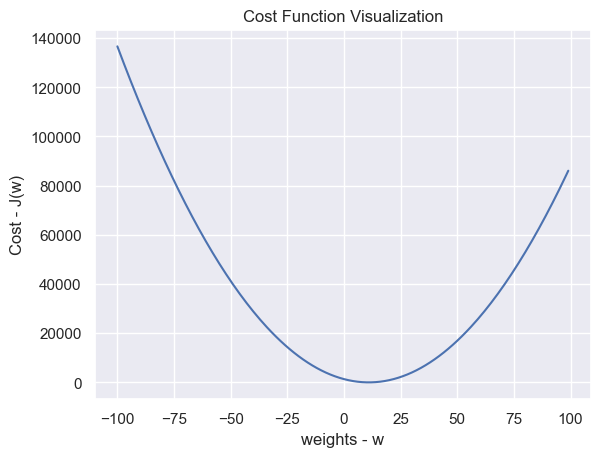

In [ ]:
w_range = []
cost_history = []

# Loop through different weight values to see how they affect the cost

for i in range(-100, 100):
    cost_i = compute_cost(X, Y, w=i, b=0) # akne call korsi compute cost k. karon akn compute cost nia graph akhbo

    w_range.append(i)
    
    cost_history.append(cost_i)

# Plotting the Cost Function: The goal of ML is to find the bottom of this 'U'
plt.plot(w_range, cost_history)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

5.Gradient Descent

Instead of guessing, we use the gradient (slope) to update  w  and  b  automatically until the cost is minimized.

In [ ]:
def calculate_gradient(X,Y,w,b):
    m=X.shape[0]
    dj_dw = 0.0 
    dj_db = 0.0 
    
    for i in range(m):
        prediction=w*X[i] + b
        error = prediction - Y[i]
        
        # Multiply error by X[i] for the weight gradient
        dj_dw =dj_dw +(error*X[i])

        # The bias gradient is just the sum of errors
        dj_db= dj_db + error

    return dj_dw/m, dj_db/m
   
        

In [45]:
def gradient_decsent(X,Y,w_input,b_input,max_iter,alpha=0.01):
    w=w_input
    b=b_input

    cost_memo=[]
    iteration=[]

    for i in range(max_iter):
        dj_dw, dj_db=calculate_gradient(X,Y,w,b)

         # 2.Update parameters by taking a small step (alpha) against the gradient

        w= w - alpha*dj_dw
        b= b - alpha*dj_db

        cost=compute_cost(X,Y,w,b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 10 == 0: # Print cost every 10 iterations
            print(f"Iteration {i}: Cost {cost}, w: {w}, b: {b}")

            return w,b, cost_memo, iteration        

        

        


In [46]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_decsent(X, Y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

Iteration 0: Cost 790.37166, w: 2.43, b: 0.47000000000000003
